In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 1. Định nghĩa Palette màu "cứng"
GRIDBREAKER_COLORS = {
    'primary': '#1D4E89',    # Blue - Chỉ số chính (Revenue, Orders)
    'secondary': '#F2A900',  # Gold - Điểm nhấn, Insight
    'neutral': '#E5E5E5',    # Grey - Dữ liệu nền
    'alert': '#D72638',      # Red - Tiêu cực (Return, Stockout)
    'success': '#4CAF50',    # Green - Tích cực (Retention, ROI)
    'info': '#00B4D8'        # Light Blue - Bổ trợ
}

# 2. Tạo một danh sách màu để dùng cho các biểu đồ Categorical (nhiều nhóm)
CUSTOM_PALETTE = [
    GRIDBREAKER_COLORS['primary'],
    GRIDBREAKER_COLORS['secondary'],
    GRIDBREAKER_COLORS['info'],
    GRIDBREAKER_COLORS['success'],
    GRIDBREAKER_COLORS['alert']
]

# 3. Cấu hình mặc định cho toàn bộ Notebook
def setup_chart_style():
    sns.set_theme(style="whitegrid") # Nền trắng lưới xám nhạt cho sạch
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelcolor'] = '#333333'
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10

    # Set palette mặc định cho Seaborn
    sns.set_palette(sns.color_palette(CUSTOM_PALETTE))

setup_chart_style()

# **INSIGHT 1: TỐI ƯU CHUỖI CUNG ỨNG**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/inventory_cleaned.csv'
df_inventory = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_inventory.head())

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5


In [ ]:
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   snapshot_date      60247 non-null  object 
 1   product_id         60247 non-null  int64  
 2   stock_on_hand      60247 non-null  int64  
 3   units_received     60247 non-null  int64  
 4   units_sold         60247 non-null  int64  
 5   stockout_days      60247 non-null  int64  
 6   days_of_supply     60247 non-null  float64
 7   fill_rate          60247 non-null  float64
 8   stockout_flag      60247 non-null  int64  
 9   overstock_flag     60247 non-null  int64  
 10  reorder_flag       60247 non-null  int64  
 11  sell_through_rate  60247 non-null  float64
 12  product_name       60247 non-null  object 
 13  category           60247 non-null  object 
 14  segment            60247 non-null  object 
 15  year               60247 non-null  int64  
 16  month              602

In [ ]:
condition_check = (df_inventory['units_sold'] <= df_inventory['units_received']).all()
print(f"Is units_sold always less than or equal to units_received? {condition_check}")

Is units_sold always less than or equal to units_received? True


In [ ]:
df_filtered = df_inventory[df_inventory['product_id'] == 763]
df_sorted = df_filtered.sort_values(by='snapshot_date')
display(df_sorted.head(20))

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
15314,2013-10-31,763,9,3,3,2,90.0,0.9333,1,0,0,0.2500,HanoiStreet RP-51,Outdoor,Activewear,2013,10
15315,2013-11-30,763,43,214,180,28,7.2,0.0667,1,0,0,0.8072,HanoiStreet RP-51,Outdoor,Activewear,2013,11
15316,2013-12-31,763,82,191,152,21,16.2,0.3000,1,0,0,0.6496,HanoiStreet RP-51,Outdoor,Activewear,2013,12
15317,2014-01-31,763,104,164,142,12,22.0,0.6000,1,0,0,0.5772,HanoiStreet RP-51,Outdoor,Activewear,2014,1
15318,2014-02-28,763,121,134,117,3,31.0,0.9000,1,0,0,0.4916,HanoiStreet RP-51,Outdoor,Activewear,2014,2
15319,2014-03-31,763,155,171,137,3,33.9,0.9000,1,0,0,0.4692,HanoiStreet RP-51,Outdoor,Activewear,2014,3
15320,2014-04-30,763,183,163,135,1,40.7,0.9667,1,0,0,0.4245,HanoiStreet RP-51,Outdoor,Activewear,2014,4
15321,2014-05-31,763,205,115,93,1,66.1,0.9667,1,0,0,0.3121,HanoiStreet RP-51,Outdoor,Activewear,2014,5
15322,2014-06-30,763,221,83,67,2,99.0,0.9333,1,1,0,0.2326,HanoiStreet RP-51,Outdoor,Activewear,2014,6
15323,2014-07-31,763,230,43,34,0,202.9,1.0000,0,1,0,0.1288,HanoiStreet RP-51,Outdoor,Activewear,2014,7


In [ ]:
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

def check_increasing(group):
    group = group.sort_values('snapshot_date')
    return group['stock_on_hand'].is_monotonic_increasing

stock_trend_check = df_inventory.groupby('product_id').apply(check_increasing)

overall_increasing = stock_trend_check.all()
print(f"Is stock_on_hand always increasing for every product? {overall_increasing}")

if not overall_increasing:
    decreasing_products = stock_trend_check[~stock_trend_check].index.tolist()
    print(f"Number of products with decreasing stock trends: {len(decreasing_products)}")
    print(f"Example product IDs with decreasing trends: {decreasing_products[:10]}")

Is stock_on_hand always increasing for every product? True


**Phân tích Tầm quan trọng của Sell-Through Rate trong Quản trị Tồn kho**

Nhìn vào cấu trúc dữ liệu và thực tế vận hành, chúng ta thấy một bức tranh rất đặc thù: Lượng tồn kho `stock_on_hand` liên tục tăng theo thời gian và lượng hàng nhập (units_received) luôn lớn hơn lượng bán ra `units_sold`. Việc các đơn hàng được đáp ứng chủ yếu từ nguồn hàng mới nhập thay vì giải phóng hàng tồn đọng phản ánh một chiến lược kinh doanh chủ đích của doanh nghiệp (có thể là chiến lược Push - ưu tiên bán bộ sưu tập mới nhất hoặc tích trữ quy mô lớn để bành trướng thị phần).

Trong bối cảnh chiến lược này, `sell_through_rate` vươn lên trở thành biến số quan trọng nhất, mang tính quyết định đối với việc phân tích doanh thu. Dưới đây là lý do:
- **Sự Hạn Chế Của Các Biến Số Khác Trong Việc Đánh Giá Doanh Thu:**
  + Các chỉ số tuyệt đối `stock_on_hand`, `units_received`: Khi doanh nghiệp chủ động duy trì chiến lược "bơm hàng", sự gia tăng của các biến này mất đi ý nghĩa đo lường hiệu quả bán hàng. Chúng chỉ đơn thuần phản ánh quy mô của khâu mua hàng (Procurement), không phản ánh được hàng hóa đó có mang lại tiền hay không.
  + Các biến cờ hiệu `overstock_flag`, `stockout_flag`: Mặc dù logic toán học giữa các biến này rất chặt chẽ và chính xác, nhưng chúng quá nhạy (chỉ cần 1 ngày trong tháng chạm ngưỡng là cờ sẽ bật giá trị 1). Đặc tính này khiến chúng trở thành các biến cảnh báo rủi ro (Risk Alerts) tuyệt vời cho đội ngũ vận hành kho, nhưng lại thiếu độ mịn để phân tích sức khỏe doanh thu xuyên suốt cả tháng.
- **Sell-Through Rate: Thước Đo Hiệu Suất Chuyển Hóa Vốn Thành Tiền:**
  + `sell_through_rate` là biến liên tục duy nhất được chuẩn hóa để đo lường hiệu quả thực sự. Dưới góc nhìn quản trị doanh thu, nó đại diện cho Tốc độ quay vòng vốn (Capital Turnover).
  + Khi hàng tồn kho liên tục phình to, tổng doanh thu có thể vẫn tăng, tạo ra "ảo giác" về sự tăng trưởng. Tuy nhiên, nếu `sell_through_rate` giảm, điều đó có nghĩa là tốc độ tạo ra doanh thu đang không theo kịp tốc độ chôn vốn nhập hàng.
  + Biến số này trả lời cho câu hỏi sinh tử: "Trên mỗi 1 đồng tài sản nằm trong kho, chúng ta chuyển hóa được bao nhiêu đồng thành doanh thu thực tế trong tháng đó?"
- **Định Lượng Rủi Ro Lợi Nhuận Gộp (Margin Risk) Từ Bãi "Dead Stock":**
  + Với hiện tượng hàng bán ra luôn được lấy từ lô mới `units_received`, hệ quả tất yếu là lượng hàng cũ nằm dưới đáy kho sẽ ngày càng tích tụ và lỗi thời (đặc biệt rủi ro với nhóm hàng có tính xu hướng cao như Streetwear và Casual).
  + Sự dịch chuyển hoặc sụt giảm của `sell_through_rate` là chỉ báo sớm (Leading Indicator) cảnh báo về sự phình to của bãi hàng tồn này.
  + Khi tỷ lệ này rớt xuống một ngưỡng nhất định, nó giải thích trực tiếp cho các hiện tượng bất thường ở bảng Sales: Doanh nghiệp sẽ bắt buộc phải chạy các chiến dịch xả hàng cắt máu, dẫn đến tình trạng biên lợi nhuận âm (`COGS` > `Revenue`).
- *Tỷ lệ này càng cao, chứng tỏ hàng hóa bán càng chạy, thu hồi vốn càng nhanh và không tốn chi phí lưu kho. Tỷ lệ thấp báo hiệu tình trạng ứ đọng vốn (dead stock) và nguy cơ phải bán phá giá để cắt lỗ.*

### Phân tích Sell-Through Rate theo thời gian và phân khúc

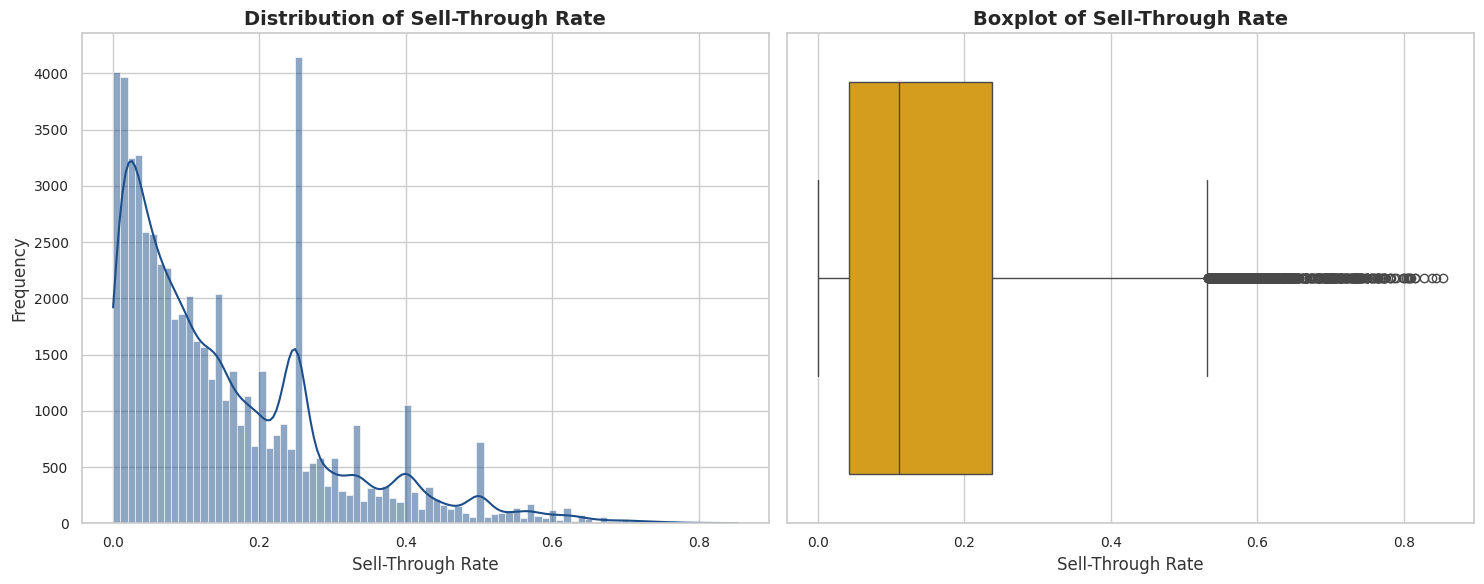

,sell_through_rate
count,60247.000000
mean,0.152275
std,0.139291
min,0.000400
25%,0.042100
50%,0.111100
75%,0.238100
max,0.853100


In [ ]:
# Phân phối của Sell-Through Rate trên df_inventory
plt.figure(figsize=(15, 6))

# Subplot 1: Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df_inventory['sell_through_rate'], kde=True, color=GRIDBREAKER_COLORS['primary'])
plt.title('Distribution of Sell-Through Rate')
plt.xlabel('Sell-Through Rate')
plt.ylabel('Frequency')

# Subplot 2: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_inventory['sell_through_rate'], color=GRIDBREAKER_COLORS['secondary'])
plt.title('Boxplot of Sell-Through Rate')
plt.xlabel('Sell-Through Rate')

plt.tight_layout()
plt.show()

# Hiển thị thống kê mô tả
display(df_inventory['sell_through_rate'].describe())

In [ ]:
# 1. Tính toán các ngưỡng của IQR
Q1 = df_inventory['sell_through_rate'].quantile(0.25)
Q3 = df_inventory['sell_through_rate'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# 2. Lọc các dòng bị coi là outliers (vượt ngưỡng trên)
df_outliers = df_inventory[df_inventory['sell_through_rate'] > upper_bound].copy()

# 3. Thống kê các tháng/năm có nhiều outliers nhất
outlier_summary = df_outliers.groupby(['year', 'month']).size().reset_index(name='outlier_count')
outlier_summary = outlier_summary.sort_values(by='outlier_count', ascending=False)

print(f"Ngưỡng xác định outlier (Upper Bound): {upper_bound:.4f}")
print(f"Tổng số dòng bị coi là outlier: {len(df_outliers)}")
print("\nCác tháng/năm có số lượng sản phẩm đạt STR ngoại lai cao nhất:")
display(outlier_summary.head(10))

# 4. Hiển thị chi tiết một số sản phẩm outlier
print("\nChi tiết một số dòng outlier:")
display(df_outliers[['snapshot_date', 'product_name', 'sell_through_rate', 'units_sold', 'units_received']].head())

Ngưỡng xác định outlier (Upper Bound): 0.5321
Tổng số dòng bị coi là outlier: 1284

Các tháng/năm có số lượng sản phẩm đạt STR ngoại lai cao nhất:


,year,month,outlier_count
0,2012,8,26
20,2014,4,26
32,2015,4,25
70,2018,6,24
16,2013,12,23
1,2012,9,23
8,2013,4,23
102,2021,4,21
48,2016,8,21
2,2012,10,20



Chi tiết một số dòng outlier:


,snapshot_date,product_name,sell_through_rate,units_sold,units_received
128,2019-04-30,DragonWear MA-07,0.5714,4,4
299,2013-02-28,DragonWear MA-10,0.6000,6,7
300,2013-03-31,DragonWear MA-10,0.5556,5,5
321,2021-09-30,DragonWear MA-12,0.5714,4,4
325,2019-04-30,DragonWear MA-13,0.6000,6,7


In [ ]:
outlier_summary

,year,month,outlier_count
0,2012,8,26
20,2014,4,26
32,2015,4,25
70,2018,6,24
16,2013,12,23
...,...,...,...
73,2018,9,1
89,2020,1,1
75,2018,11,1
99,2020,11,1


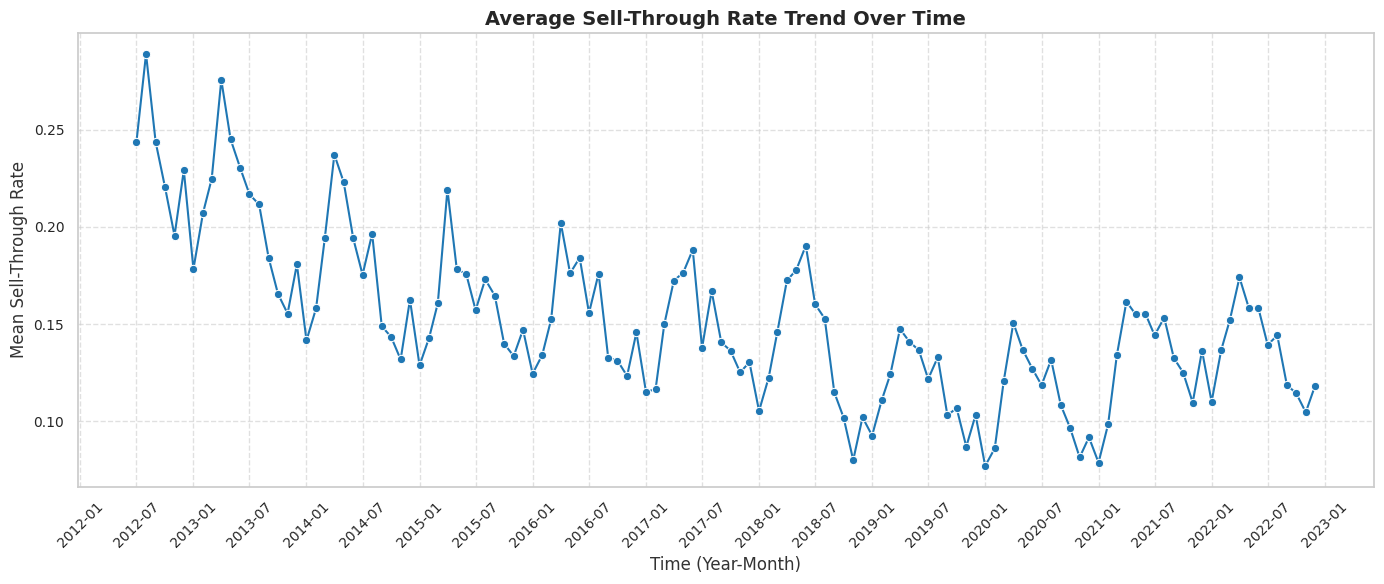

In [ ]:
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6)) # Tăng chiều rộng để biểu đồ thoáng hơn

# 1. Tính toán
df_monthly = df_inventory.groupby(['year', 'month'])['sell_through_rate'].mean().reset_index()

# 2. Tạo cột Datetime chuẩn thay vì ghép chuỗi text
# Hàm assign(DAY=1) để Pandas hiểu đây là ngày mùng 1 của tháng đó
df_monthly['date'] = pd.to_datetime(df_monthly[['year', 'month']].assign(DAY=1))

# 3. Vẽ biểu đồ (Đổi x thành 'date')
sns.lineplot(
    data=df_monthly,
    x='date',
    y='sell_through_rate',
    marker='o',
    color='#1f77b4' # Bạn có thể thay lại bằng GRIDBREAKER_COLORS['primary'] của bạn
)

plt.title('Average Sell-Through Rate Trend Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Mean Sell-Through Rate', fontsize=12)
plt.xlabel('Time (Year-Month)', fontsize=12)

# ==========================================
# 4. FIX TRỤC X: Giãn cách nhãn để không bị đè
# ==========================================
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # Cứ 6 tháng mới hiện 1 nhãn
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Format dạng Năm-Tháng
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Lệnh này rất quan trọng để nhãn không bị cắt lẹm khỏi hình
plt.show()

**Nhận xét:**
- **Tốc độ quay vòng vốn đang đuối dần (Nhìn vào độ dốc của đồ thị):** Khả năng chuyển hóa hàng trong kho thành doanh thu đang bị suy giảm. Doanh nghiệp đang ngày càng mất nhiều thời gian hơn để bán được hàng.
- **Bằng chứng toán học của việc tích tụ "Dead Stock":** Vì tỷ lệ Sell-Through = (Bán ra / Nhập vào), việc đường đồ thị liên tục đi xuống chứng tỏ mẫu số (lượng hàng nhập) đang áp đảo hoàn toàn tử số (lượng hàng bán ra). Lượng hàng không bán được của tháng này sẽ dồn xuống tháng sau.
- **Chỉ ra thời điểm gánh chịu "Lỗ gộp" (COGS > Revenue:)**

In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/sales_cleaned.csv'
df_sales = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_sales.head())

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [ ]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   object 
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), object(1)
memory usage: 90.0+ KB


In [ ]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['Gross_Profit'] = df_sales['Revenue'] - df_sales['COGS']

# Filter for negative margin days
df_negative_margin = df_sales[df_sales['Gross_Profit'] < 0].sort_values('Date')

print(f"Number of days with negative gross margin: {len(df_negative_margin)}")
display(df_negative_margin)

Number of days with negative gross margin: 382


,Date,Revenue,COGS,Gross_Profit
392,2013-07-31,10104475.36,10851542.12,-747066.76
393,2013-08-01,10998208.40,12167214.07,-1169005.67
394,2013-08-02,7422715.15,9601836.11,-2179120.96
395,2013-08-03,5599602.67,7786528.35,-2186925.68
396,2013-08-04,5021938.29,7089757.76,-2067819.47
...,...,...,...,...
3827,2022-12-26,2110830.12,2160963.69,-50133.57
3828,2022-12-27,2100553.66,2184872.24,-84318.58
3829,2022-12-28,3448729.20,3513621.00,-64891.80
3830,2022-12-29,3083944.33,3170787.10,-86842.77


In [ ]:
df_negative_margin['Year_Month'] = df_negative_margin['Date'].dt.to_period('M')
unique_negative_months = df_negative_margin['Year_Month'].unique().tolist()
unique_negative_months.sort()

print("Các tháng và năm có biên lợi nhuận âm:")
for month in unique_negative_months:
    print(month)

Các tháng và năm có biên lợi nhuận âm:
2013-07
2013-08
2013-09
2013-11
2013-12
2014-07
2014-11
2014-12
2015-08
2015-09
2015-11
2015-12
2016-07
2016-11
2016-12
2017-07
2017-08
2017-09
2017-11
2017-12
2018-07
2018-11
2018-12
2019-07
2019-08
2019-09
2019-11
2019-12
2020-06
2020-07
2020-11
2020-12
2021-06
2021-07
2021-08
2021-09
2021-11
2021-12
2022-01
2022-06
2022-07
2022-11
2022-12


In [ ]:
# Lấy danh sách các cặp (Năm, Tháng) từ các tháng có lợi nhuận âm
negative_periods = [(p.year, p.month) for p in unique_negative_months]

# Lọc df_inventory dựa trên danh sách này
def is_negative_period(row):
    return (row['year'], row['month']) in negative_periods

df_inventory_neg_margin = df_inventory[df_inventory.apply(is_negative_period, axis=1)]

# Tính toán Sell-Through Rate trung bình cho các tháng này
str_neg_margin = df_inventory_neg_margin.groupby(['year', 'month'])['sell_through_rate'].mean().reset_index()
str_neg_margin['period'] = str_neg_margin['year'].astype(str) + '-' + str_neg_margin['month'].astype(str).str.zfill(2)
str_neg_margin = str_neg_margin.sort_values(['year', 'month'])

print("Sell-Through Rate trung bình trong các tháng có biên lợi nhuận âm:")
display(str_neg_margin[['period', 'sell_through_rate']])

# So sánh với Sell-Through Rate trung bình toàn bộ
overall_avg_str = df_inventory['sell_through_rate'].mean()
neg_period_avg_str = str_neg_margin['sell_through_rate'].mean()

print(f"\nAverage STR overall: {overall_avg_str:.4f}")
print(f"Average STR during negative margin months: {neg_period_avg_str:.4f}")

Sell-Through Rate trung bình trong các tháng có biên lợi nhuận âm:


,period,sell_through_rate
0,2013-07,0.216677
1,2013-08,0.211489
2,2013-09,0.183943
3,2013-11,0.155431
4,2013-12,0.180734
5,2014-07,0.175390
6,2014-11,0.131828
7,2014-12,0.162554
8,2015-08,0.173031
9,2015-09,0.164631



Average STR overall: 0.1523
Average STR during negative margin months: 0.1380


**Nhận xét về mối tương quan giữa Sell-Through Rate (STR) và Lợi nhuận âm**

**1. Mối liên hệ trực tiếp giữa STR và Lợi nhuận:**
- Việc lấy ra danh sách các tháng có biên lợi nhuận âm đồng nghĩa với việc xác định các giai đoạn mà **Sell-Through Rate (STR) đang ở mức rất tệ**.
- Khi STR sụt giảm (trung bình chỉ đạt **0.1380** so với mức 0.1523 của toàn bộ dữ liệu), hàng hóa bị ứ đọng trong kho. Để giải phóng lượng "Dead Stock" này và thu hồi vốn, doanh nghiệp buộc phải chấp nhận bán lỗ hoặc giảm giá sâu, dẫn đến tình trạng **COGS > Revenue**.

**2. Danh sách các tháng có hiệu suất STR tệ dẫn đến lợi nhuận âm:**

Dựa trên phân tích, đây là các giai đoạn doanh nghiệp gặp khủng hoảng về tốc độ lưu chuyển hàng hóa và biên lợi nhuận:

*   **2013:** Tháng 07, 08, 09, 11, 12
*   **2014:** Tháng 07, 11, 12
*   **2015:** Tháng 08, 09, 11, 12
*   **2016:** Tháng 07, 11, 12
*   **2017:** Tháng 07, 08, 09, 11, 12
*   **2018:** Tháng 07, 11, 12
*   **2019:** Tháng 07, 08, 09, 11, 12
*   **2020:** Tháng 06, 07, 11, 12
*   **2021:** Tháng 06, 07, 08, 09, 11, 12
*   **2022:** Tháng 01, 06, 07, 11, 12

In [ ]:
# 1. Tính tổng Gross Profit theo từng tháng
df_sales['Year_Month'] = df_sales['Date'].dt.to_period('M')
monthly_profit = df_sales.groupby('Year_Month')['Gross_Profit'].sum().reset_index()

# 2. Lấy Top 10 tháng có lợi nhuận cao nhất
top_profit_months = monthly_profit.sort_values(by='Gross_Profit', ascending=False).head(10)

print("Top 10 tháng có Gross Profit cao nhất:")
display(top_profit_months)

# 3. Trích xuất danh sách cặp (năm, tháng) để lọc bên Inventory
top_periods = [(p.year, p.month) for p in top_profit_months['Year_Month']]

Top 10 tháng có Gross Profit cao nhất:


,Year_Month,Gross_Profit
70,2018-05,54184728.46
46,2016-05,52882578.42
58,2017-05,51840649.98
34,2015-05,49244619.80
22,2014-05,49115634.24
71,2018-06,45327968.14
49,2016-08,45098760.96
59,2017-06,42167185.21
33,2015-04,42031250.76
10,2013-05,40740955.68


In [ ]:
# 4. Lọc df_inventory cho các tháng top này
def is_top_period(row):
    return (row['year'], row['month']) in top_periods

df_inventory_top_margin = df_inventory[df_inventory.apply(is_top_period, axis=1)]

# 5. Tính Sell-Through Rate trung bình cho các tháng top
str_top_margin = df_inventory_top_margin.groupby(['year', 'month'])['sell_through_rate'].mean().reset_index()
str_top_margin['period'] = str_top_margin['year'].astype(str) + '-' + str_top_margin['month'].astype(str).str.zfill(2)
str_top_margin = str_top_margin.sort_values(['year', 'month'])

print("\nSell-Through Rate trong các tháng có lợi nhuận cao nhất:")
display(str_top_margin[['period', 'sell_through_rate']])

# 6. So sánh với các chỉ số khác
top_period_avg_str = str_top_margin['sell_through_rate'].mean()
overall_avg_str = df_inventory['sell_through_rate'].mean()

print(f"\nAverage STR during TOP profit months: {top_period_avg_str:.4f}")
print(f"Average STR overall: {overall_avg_str:.4f}")
print(f"Average STR during negative margin months: 0.1380")


Sell-Through Rate trong các tháng có lợi nhuận cao nhất:


,period,sell_through_rate
0,2013-05,0.244962
1,2014-05,0.223013
2,2015-04,0.219131
3,2015-05,0.178499
4,2016-05,0.176151
5,2016-08,0.176005
6,2017-05,0.176385
7,2017-06,0.188207
8,2018-05,0.177781
9,2018-06,0.190360



Average STR during TOP profit months: 0.1950
Average STR overall: 0.1523
Average STR during negative margin months: 0.1380


**Đánh giá Tổng quan về Hiệu suất Vận hành và Chuỗi cung ứng**

Từ các phân tích trên, chúng ta có thể rút ra những kết luận quan trọng về thực trạng của doanh nghiệp:

**1. Sell-Through Rate (STR) thấp là vấn đề hệ thống:**
- Dù ở giai đoạn **biên lợi nhuận cao nhất (STR ~0.1950)** hay giai đoạn **lỗ gộp (STR ~0.1380)**, tỷ lệ Sell-Through Rate nhìn chung vẫn ở mức rất thấp so với kỳ vọng thông thường của ngành bán lẻ.
- Việc STR không có sự bứt phá đáng kể ngay cả trong những tháng doanh thu đỉnh điểm cho thấy hàng hóa đang được "đẩy" vào kho nhanh hơn nhiều so với tốc độ thị trường có thể hấp thụ.

**2. Sự lệch pha giữa Doanh thu và Hiệu suất kho:**
- Các tháng có số lượng **Outliers (sản phẩm bán cực chạy) không nằm trong nhóm các tháng có lợi nhuận cao nhất**. Điều này chứng tỏ lợi nhuận của doanh nghiệp đang phụ thuộc vào việc bán dàn trải số lượng lớn với chi phí vận hành cao, chứ không phải nhờ vào việc tối ưu hóa các sản phẩm "Hero items".

**3. Dấu hiệu bất ổn trong Supply Chain Operation:**
- **Tồn kho phình to (Overstocking):** Doanh nghiệp dường như đang duy trì một lượng hàng tồn kho quá lớn (mẫu số cao), dẫn đến việc STR bị kéo thấp xuống một cách hệ thống.
- **Áp lực xả hàng:** Khi STR duy trì ở mức thấp quá lâu, doanh nghiệp rơi vào cái bẫy "Dead Stock", buộc phải giảm giá sâu vào các tháng cuối năm để giải phóng kho, dẫn đến biên lợi nhuận âm như đã quan sát.
- **Vấn đề dự báo:** Sự thiếu tương quan giữa các sản phẩm bán chạy nhất (outliers) và các tháng lợi nhuận cao nhất cho thấy công tác dự báo nhu cầu (Demand Forecasting) và phân bổ hàng hóa (Allocation) đang có lỗ hổng lớn.

**Kết luận:** Doanh nghiệp không chỉ gặp vấn đề ở khâu bán hàng mà thực chất đang đối mặt với **khủng hoảng hiệu suất chuỗi cung ứng**. Việc tích trữ hàng quá mức đang chôn vùi dòng tiền và trực tiếp bào mòn lợi nhuận thông qua chi phí lưu kho và áp lực giảm giá.

**Kiểm định mối liên hệ giữa Sell-Through Rate và Doanh thu**

In [ ]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

# 1. Aggregate df_sales to monthly revenue
df_sales['year_month'] = df_sales['Date'].dt.to_period('M')
monthly_revenue = df_sales.groupby('year_month')['Revenue'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].dt.to_timestamp()

# 2. Aggregate df_inventory to monthly average sell_through_rate
df_inventory['year_month'] = df_inventory['snapshot_date'].dt.to_period('M')
monthly_str = df_inventory.groupby('year_month')['sell_through_rate'].mean().reset_index()
monthly_str['year_month'] = monthly_str['year_month'].dt.to_timestamp()

# 3. Merge the two aggregated dataframes
merged_df = pd.merge(monthly_revenue, monthly_str, on='year_month', how='inner')

# Display the merged dataframe
display(merged_df.head())


,year_month,Revenue,sell_through_rate
0,2012-07-01,1.304068e+08,0.243548
1,2012-08-01,1.590892e+08,0.288848
2,2012-09-01,1.293071e+08,0.243615
3,2012-10-01,1.101857e+08,0.220611
4,2012-11-01,9.818630e+07,0.195454


Correlation between Monthly Average Sell-Through Rate and Monthly Revenue: 0.6474


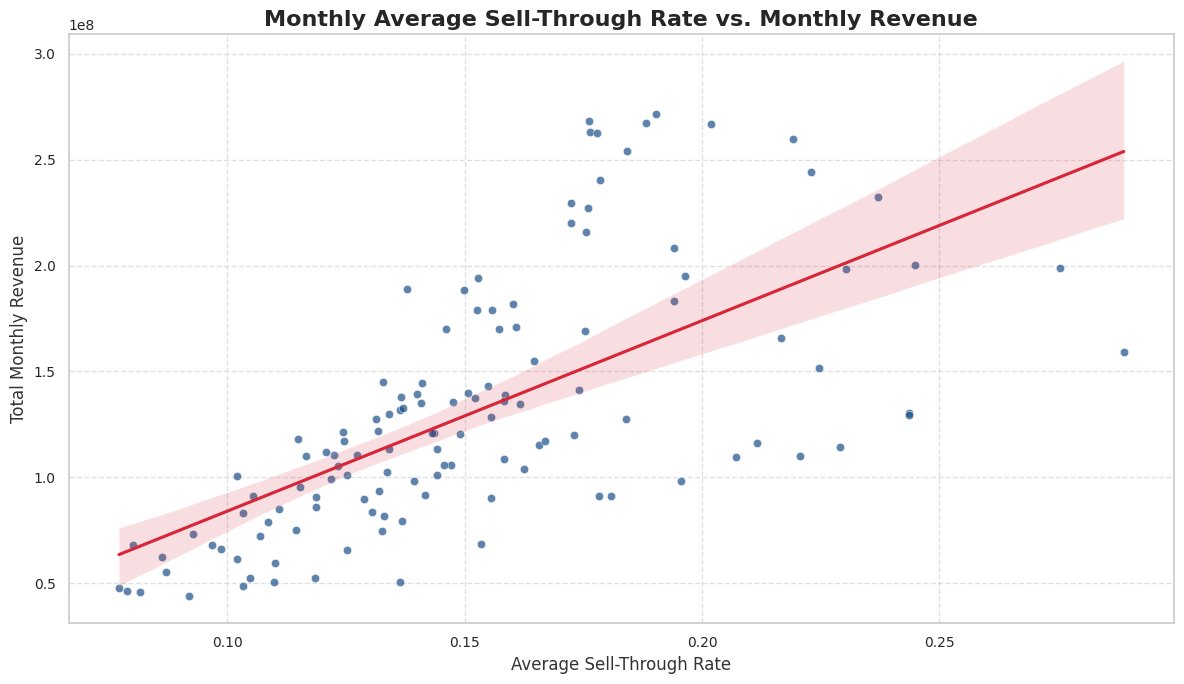

In [ ]:
# 4. Calculate correlation
correlation = merged_df['sell_through_rate'].corr(merged_df['Revenue'])
print(f"Correlation between Monthly Average Sell-Through Rate and Monthly Revenue: {correlation:.4f}")

# 5. Visualize the relationship with a scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(x='sell_through_rate', y='Revenue', data=merged_df, color=GRIDBREAKER_COLORS['primary'], alpha=0.7)
sns.regplot(x='sell_through_rate', y='Revenue', data=merged_df, scatter=False, color=GRIDBREAKER_COLORS['alert'])
plt.title('Monthly Average Sell-Through Rate vs. Monthly Revenue', fontsize=16)
plt.xlabel('Average Sell-Through Rate', fontsize=12)
plt.ylabel('Total Monthly Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Nhận xét:**
-  `sell_through_rate` là một chỉ số quan trọng, có ảnh hưởng đáng kể đến doanh thu của doanh nghiệp. Việc cải thiện `sell_through_rate` (tức là tăng tốc độ bán hàng và giảm tồn kho ứ đọng) có thể dẫn đến việc tăng doanh thu.

### Phân tích Sell-Through Rate theo Segment và Category

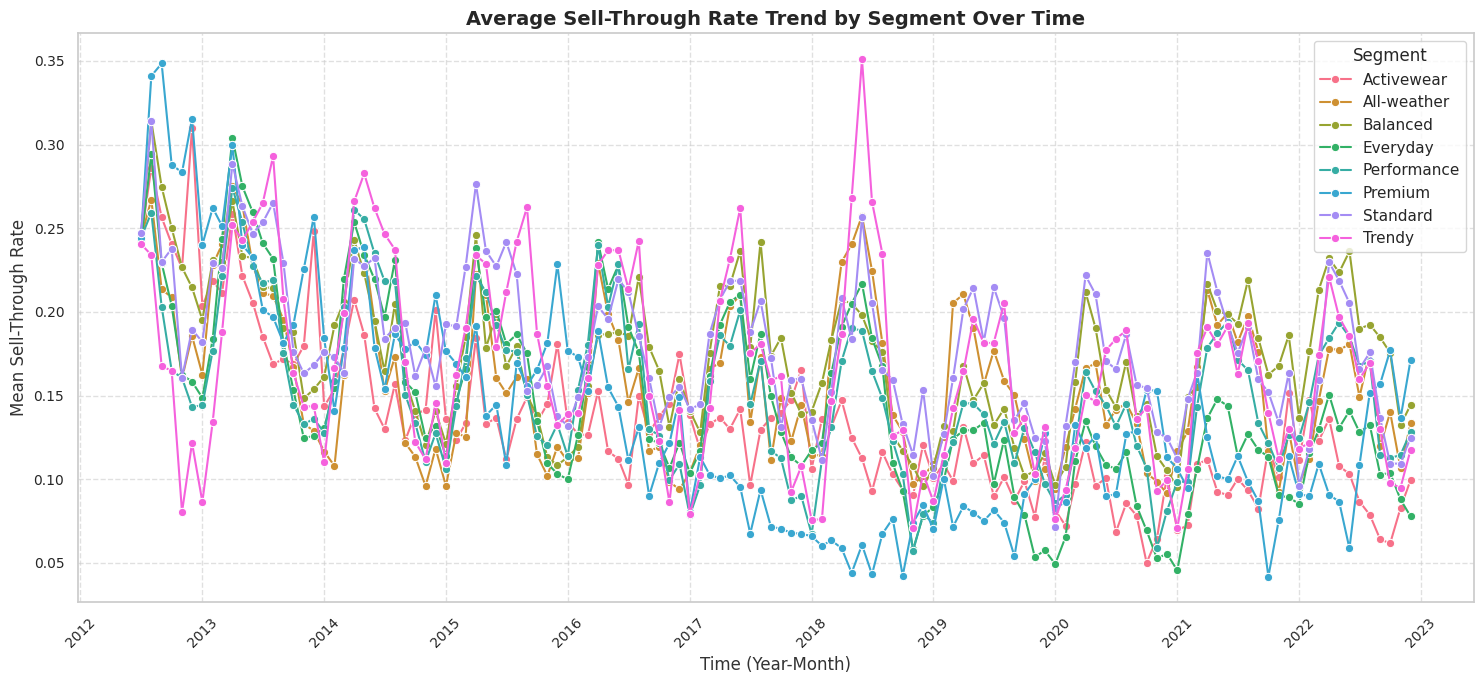

In [ ]:
import matplotlib.dates as mdates

# Chuẩn bị dữ liệu cho biểu đồ xu hướng theo Segment
df_inventory['date'] = pd.to_datetime(df_inventory[['year', 'month']].assign(day=1))
monthly_str_segment = df_inventory.groupby(['date', 'segment'])['sell_through_rate'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_str_segment, x='date', y='sell_through_rate', hue='segment', marker='o')

plt.title('Average Sell-Through Rate Trend by Segment Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Mean Sell-Through Rate', fontsize=12)
plt.xlabel('Time (Year-Month)', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator()) # Hiển thị nhãn theo năm
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format dạng Năm
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

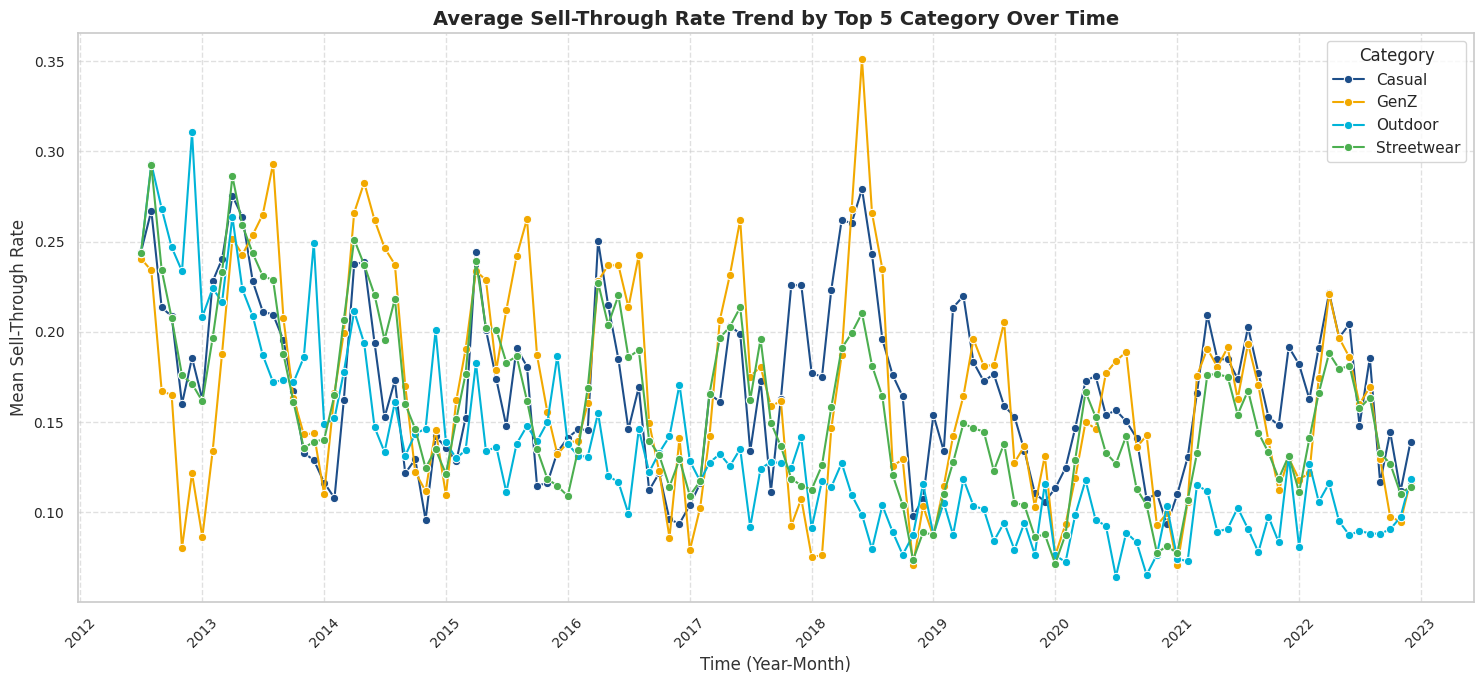

In [ ]:
# Chuẩn bị dữ liệu cho biểu đồ xu hướng theo Category
# Lấy top 5 category có sell_through_rate trung bình cao nhất để biểu đồ dễ nhìn hơn
top_categories = df_inventory.groupby('category')['sell_through_rate'].mean().nlargest(5).index
df_top_categories = df_inventory[df_inventory['category'].isin(top_categories)]

monthly_str_category = df_top_categories.groupby(['date', 'category'])['sell_through_rate'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_str_category, x='date', y='sell_through_rate', hue='category', marker='o')

plt.title('Average Sell-Through Rate Trend by Top 5 Category Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Mean Sell-Through Rate', fontsize=12)
plt.xlabel('Time (Year-Month)', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator()) # Hiển thị nhãn theo năm
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format dạng Năm
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

### Average Sell-Through Rate qua các năm

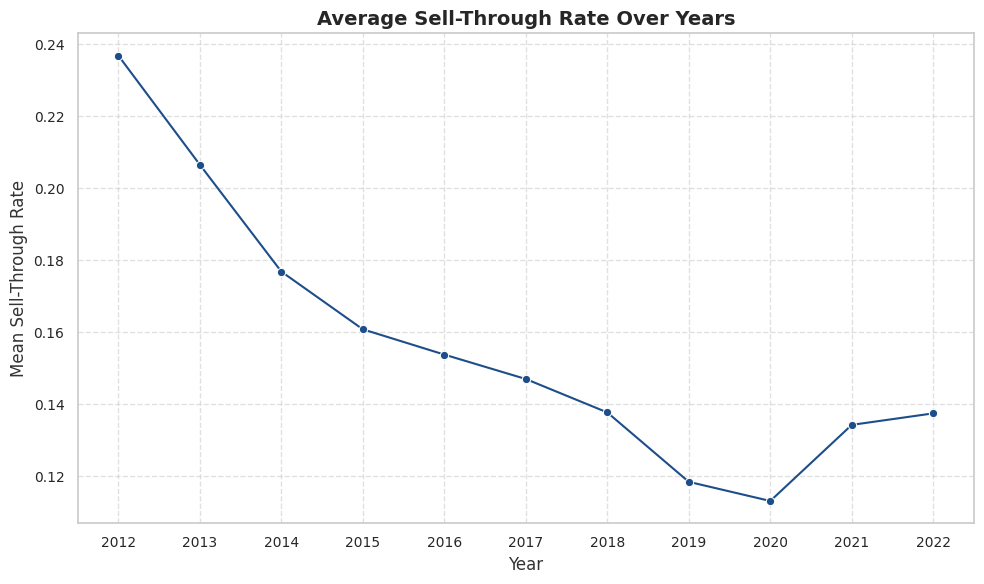

,year,sell_through_rate
0,2012,0.236818
1,2013,0.206518
2,2014,0.176848
3,2015,0.160828
4,2016,0.153811
5,2017,0.147030
6,2018,0.137749
7,2019,0.118483
8,2020,0.113169
9,2021,0.134295


In [ ]:
# Tính toán Sell-Through Rate trung bình theo từng năm
yearly_avg_str = df_inventory.groupby('year')['sell_through_rate'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_avg_str, x='year', y='sell_through_rate', marker='o', color=GRIDBREAKER_COLORS['primary'])

plt.title('Average Sell-Through Rate Over Years', fontsize=14, fontweight='bold')
plt.ylabel('Mean Sell-Through Rate', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xticks(yearly_avg_str['year'].unique()) # Đảm bảo hiển thị tất cả các năm
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(yearly_avg_str)

### Số lượng tồn kho (Stock on Hand) theo Segment (chỉ lấy ngày gần nhất cho mỗi sản phẩm)

Tổng số lượng tồn kho (stock_on_hand) theo từng Segment (chỉ lấy dữ liệu gần nhất cho mỗi sản phẩm):


,segment,stock_on_hand
0,Activewear,63777
1,All-weather,5616
2,Balanced,29482
3,Everyday,52022
4,Performance,26760
5,Premium,8167
6,Standard,2587
7,Trendy,10037


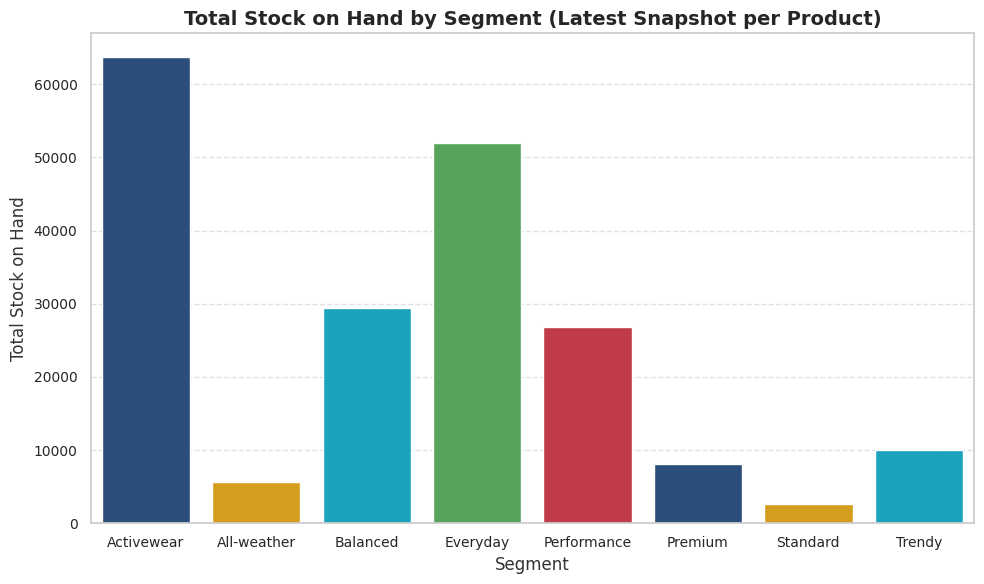

In [ ]:
# 1. Đảm bảo 'snapshot_date' là kiểu datetime (đã làm ở các bước trước nhưng kiểm tra lại)
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

# 2. Tìm ngày gần nhất cho mỗi sản phẩm
latest_stock_per_product = df_inventory.loc[df_inventory.groupby('product_id')['snapshot_date'].idxmax()]

# 3. Tính tổng 'stock_on_hand' theo từng 'segment'
stock_on_hand_by_segment = latest_stock_per_product.groupby('segment')['stock_on_hand'].sum().reset_index()

# 4. Hiển thị kết quả
print("Tổng số lượng tồn kho (stock_on_hand) theo từng Segment (chỉ lấy dữ liệu gần nhất cho mỗi sản phẩm):")
display(stock_on_hand_by_segment)

# 5. Trực quan hóa kết quả
plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='stock_on_hand', data=stock_on_hand_by_segment, palette=CUSTOM_PALETTE)
plt.title('Total Stock on Hand by Segment (Latest Snapshot per Product)', fontsize=14, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Total Stock on Hand', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Average Sell-Through Rate theo Segment

Sell-Through Rate trung bình theo từng Segment:


,segment,sell_through_rate
0,Activewear,0.137252
1,All-weather,0.156698
2,Balanced,0.174967
3,Everyday,0.148479
4,Performance,0.156052
5,Premium,0.138364
6,Standard,0.185655
7,Trendy,0.167978


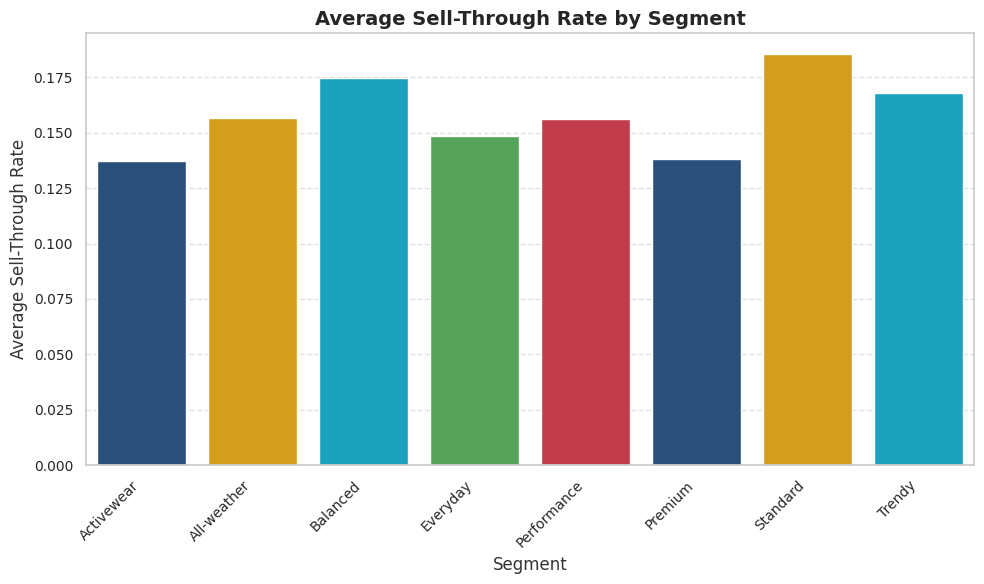

In [ ]:
# Tính toán Sell-Through Rate trung bình theo từng segment
avg_str_by_segment = df_inventory.groupby('segment')['sell_through_rate'].mean().reset_index()

print("Sell-Through Rate trung bình theo từng Segment:")
display(avg_str_by_segment)

# Trực quan hóa kết quả
plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='sell_through_rate', data=avg_str_by_segment, palette=CUSTOM_PALETTE)
plt.title('Average Sell-Through Rate by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Average Sell-Through Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Average Sell-Through Rate theo Category

Sell-Through Rate trung bình theo từng Category:


,category,sell_through_rate
0,Casual,0.168390
1,GenZ,0.167978
2,Outdoor,0.135084
3,Streetwear,0.159754


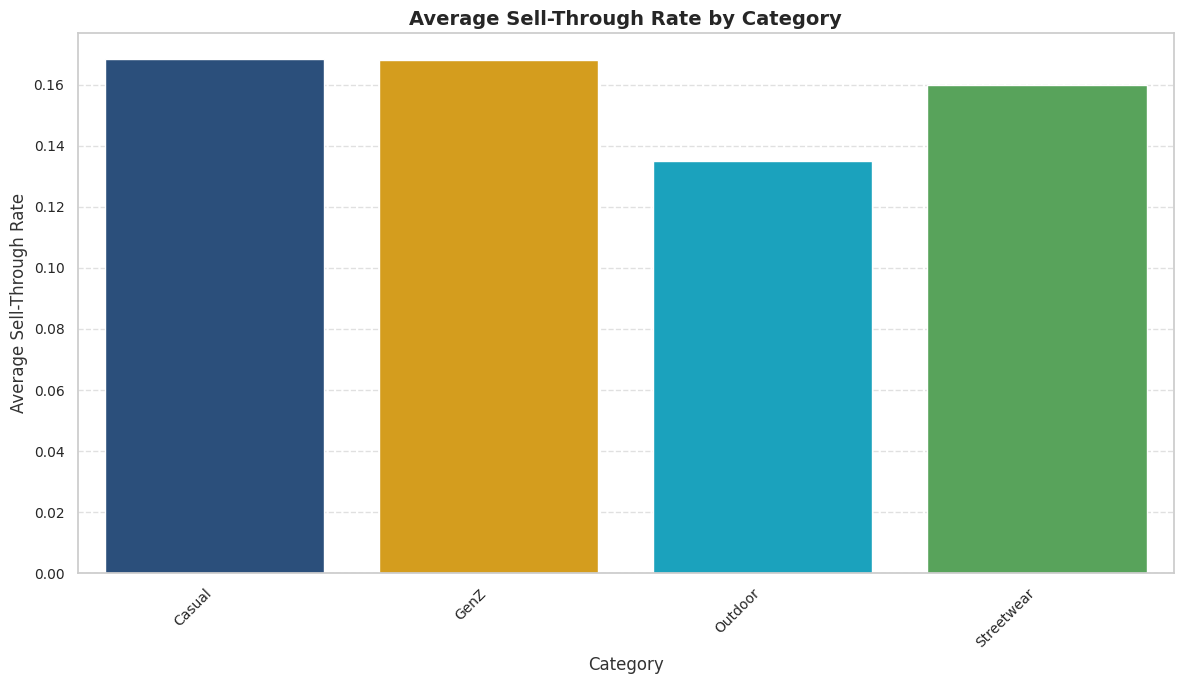

In [ ]:
# Tính toán Sell-Through Rate trung bình theo từng category
avg_str_by_category = df_inventory.groupby('category')['sell_through_rate'].mean().reset_index()

print("Sell-Through Rate trung bình theo từng Category:")
display(avg_str_by_category)

# Trực quan hóa kết quả
plt.figure(figsize=(12, 7))
sns.barplot(x='category', y='sell_through_rate', data=avg_str_by_category, palette=CUSTOM_PALETTE)
plt.title('Average Sell-Through Rate by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Sell-Through Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Số lượng tồn kho (Stock on Hand) theo Category (chỉ lấy ngày gần nhất cho mỗi sản phẩm)

Tổng số lượng tồn kho (stock_on_hand) theo từng Category (chỉ lấy dữ liệu gần nhất cho mỗi sản phẩm):


,category,stock_on_hand
0,Casual,5924
1,GenZ,10037
2,Outdoor,71636
3,Streetwear,110851


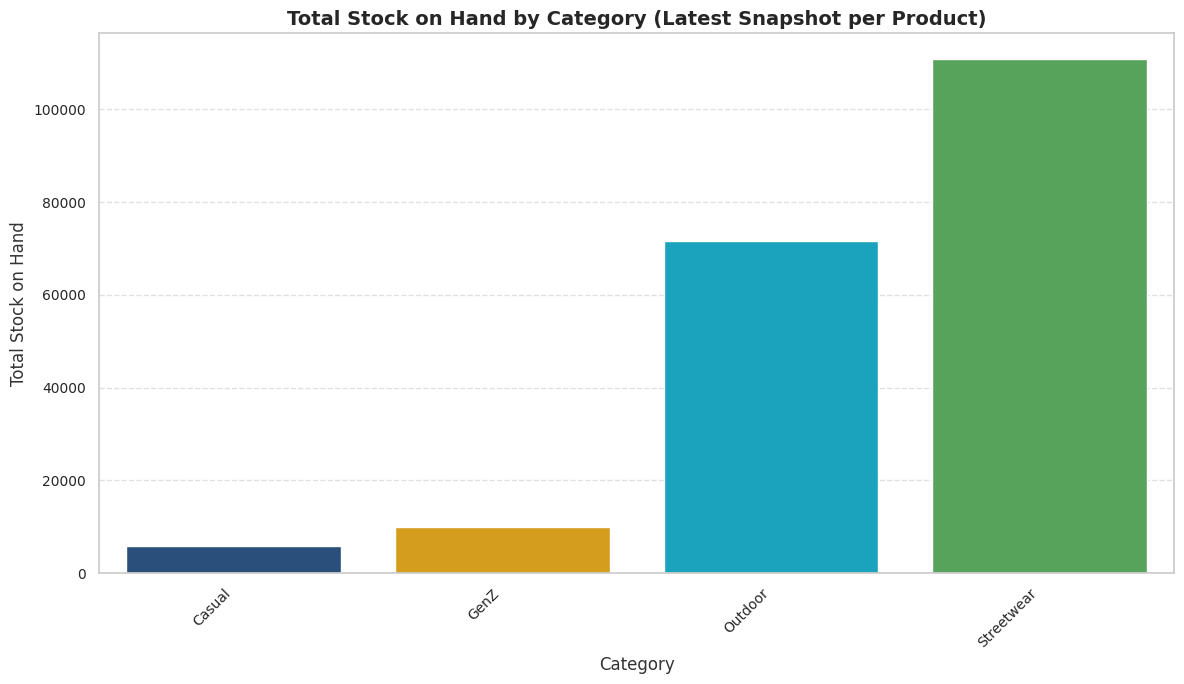

In [ ]:
# 1. Đảm bảo 'snapshot_date' là kiểu datetime (đã làm ở các bước trước nhưng kiểm tra lại)
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

# 2. Tìm ngày gần nhất cho mỗi sản phẩm
latest_stock_per_product = df_inventory.loc[df_inventory.groupby('product_id')['snapshot_date'].idxmax()]

# 3. Tính tổng 'stock_on_hand' theo từng 'category'
stock_on_hand_by_category = latest_stock_per_product.groupby('category')['stock_on_hand'].sum().reset_index()

# 4. Hiển thị kết quả
print("Tổng số lượng tồn kho (stock_on_hand) theo từng Category (chỉ lấy dữ liệu gần nhất cho mỗi sản phẩm):")
display(stock_on_hand_by_category)

# 5. Trực quan hóa kết quả
plt.figure(figsize=(12, 7))
sns.barplot(x='category', y='stock_on_hand', data=stock_on_hand_by_category, palette=CUSTOM_PALETTE)
plt.title('Total Stock on Hand by Category (Latest Snapshot per Product)', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Stock on Hand', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **INSIGHT 2**

In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_reviews.csv'
df_reviews = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_reviews.head())

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_orders.csv'
df_orders = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_orders.head())

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/geography_cleaned.csv'
df_geography = pd.read_csv(file_path)

# Loại bỏ cột Unnamed: 0
if 'Unnamed: 0' in df_geography.columns:
    df_geography = df_geography.drop(columns=['Unnamed: 0'])

# Hiển thị 5 dòng đầu tiên
display(df_geography.head())

,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13


In [ ]:
# Merge orders và geography theo cột zip (N:1)
df_orders_geo = pd.merge(df_orders, df_geography, on='zip', how='left')

# Hiển thị 5 dòng đầu tiên của kết quả
display(df_orders_geo.head())

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,city,region,district
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,Hanoi,East,District #02
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,Phu Ly,East,District #02
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,Lao Cai,East,District #02
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,Son Tay,East,District #02
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,Uong Bi,East,District #02


In [ ]:
# Merge reviews với df_orders_geo theo cột order_id (N:1)
df_reviews_full = pd.merge(df_reviews, df_orders_geo, on='order_id', how='left')

# Hiển thị 5 dòng đầu tiên để kiểm tra kết quả
display(df_reviews_full.head())

,review_id,order_id,product_id,customer_id_x,review_date,rating,review_title,order_date,customer_id_y,zip,order_status,payment_method,device_type,order_source,city,region,district
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,Hanoi,East,District #02
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,Lao Cai,East,District #02
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality,2012-07-06,49101,5262,delivered,paypal,desktop,organic_search,Thai Nguyen,East,District #01
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality,2012-07-05,41028,7830,delivered,cod,mobile,social_media,Lao Cai,East,District #03
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall,2012-07-05,42030,8016,delivered,cod,tablet,email_campaign,Lao Cai,East,District #04


In [ ]:
# Kiểm tra thông tin các cột sau khi merge
df_reviews_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   review_id       113551 non-null  object
 1   order_id        113551 non-null  int64 
 2   product_id      113551 non-null  int64 
 3   customer_id_x   113551 non-null  int64 
 4   review_date     113551 non-null  object
 5   rating          113551 non-null  int64 
 6   review_title    113551 non-null  object
 7   order_date      113551 non-null  object
 8   customer_id_y   113551 non-null  int64 
 9   zip             113551 non-null  int64 
 10  order_status    113551 non-null  object
 11  payment_method  113551 non-null  object
 12  device_type     113551 non-null  object
 13  order_source    113551 non-null  object
 14  city            113551 non-null  object
 15  region          113551 non-null  object
 16  district        113551 non-null  object
dtypes: int64(6), object(11)
memor

**Tỷ lệ giao hàng thành công và trả lại hàng theo năm**

In [ ]:
# Chuyển đổi 'order_date' sang định dạng datetime và đảm bảo đây là df_orders_geo
df_orders_geo['order_date'] = pd.to_datetime(df_orders_geo['order_date'])

# Trích xuất năm từ 'order_date'
df_orders_geo['order_year'] = df_orders_geo['order_date'].dt.year

# Đếm số lượng đơn hàng theo năm và trạng thái
status_counts = df_orders_geo.groupby(['order_year', 'order_status']).size().unstack(fill_value=0)

# Tính tổng số đơn hàng mỗi năm
status_counts['total_orders'] = status_counts.sum(axis=1)

# Tính tỷ lệ phần trăm
# Kiểm tra nếu 'delivered' hoặc 'returned' không tồn tại, gán 0 để tránh lỗi KeyError
status_counts['delivered_rate'] = (status_counts['delivered'] / status_counts['total_orders']) * 100 if 'delivered' in status_counts.columns else 0
status_counts['returned_rate'] = (status_counts['returned'] / status_counts['total_orders']) * 100 if 'returned' in status_counts.columns else 0

# Hiển thị kết quả, chỉ hiển thị các cột nếu chúng tồn tại
columns_to_display = []
if 'delivered' in status_counts.columns: columns_to_display.extend(['delivered', 'delivered_rate'])
if 'returned' in status_counts.columns: columns_to_display.extend(['returned', 'returned_rate'])

print("Tỷ lệ giao hàng thành công và trả lại hàng theo năm:")
display(status_counts[columns_to_display])

Tỷ lệ giao hàng thành công và trả lại hàng theo năm:


order_status,delivered,delivered_rate,returned,returned_rate
order_year,,,,
2012,25663,80.069265,1819,5.675330
2013,61588,80.141576,4323,5.625317
2014,64688,80.213280,4484,5.560171
2015,66163,80.079156,4621,5.592941
2016,66067,80.327550,4655,5.659781
2017,61144,80.442047,4247,5.587423
2018,55740,80.189901,3803,5.471155
2019,33259,79.947597,2300,5.528713
2020,27975,80.201256,1950,5.590436


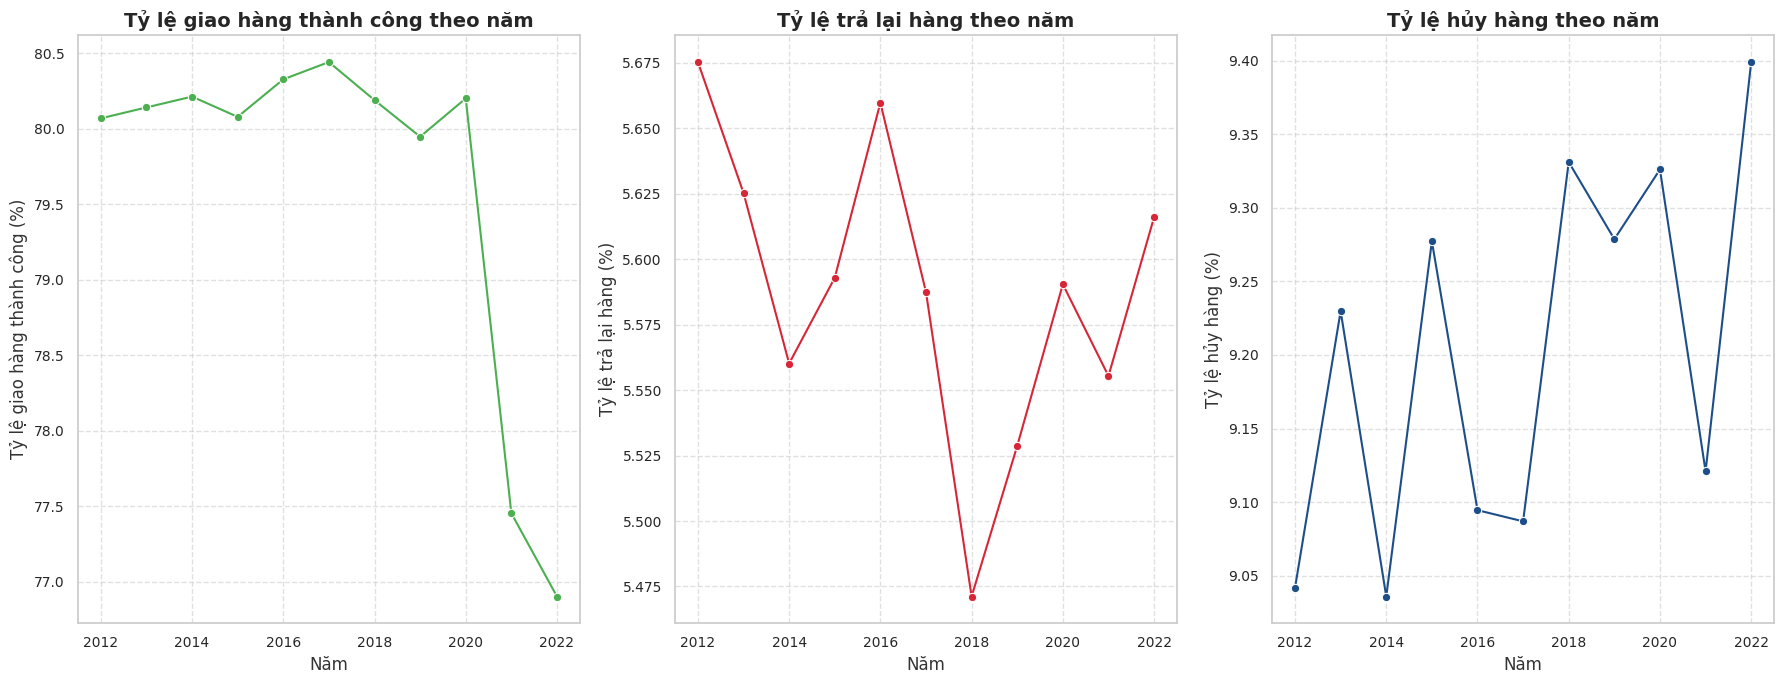

In [ ]:
# Trực quan hóa tỷ lệ giao hàng thành công, trả lại và hủy theo năm

plt.figure(figsize=(18, 7)) # Tăng kích thước để có 3 biểu đồ

# Biểu đồ tỷ lệ giao hàng thành công
plt.subplot(1, 3, 1) # 1 hàng, 3 cột, biểu đồ thứ 1
if 'delivered_rate' in status_counts.columns:
    sns.lineplot(x=status_counts.index, y='delivered_rate', data=status_counts, marker='o', color=GRIDBREAKER_COLORS['success'])
    plt.title('Tỷ lệ giao hàng thành công theo năm', fontsize=14)
    plt.xlabel('Năm', fontsize=12)
    plt.ylabel('Tỷ lệ giao hàng thành công (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
else:
    plt.text(0.5, 0.5, 'No "delivered_rate" data to plot', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

# Biểu đồ tỷ lệ trả lại hàng
plt.subplot(1, 3, 2) # 1 hàng, 3 cột, biểu đồ thứ 2
if 'returned_rate' in status_counts.columns:
    sns.lineplot(x=status_counts.index, y='returned_rate', data=status_counts, marker='o', color=GRIDBREAKER_COLORS['alert'])
    plt.title('Tỷ lệ trả lại hàng theo năm', fontsize=14)
    plt.xlabel('Năm', fontsize=12)
    plt.ylabel('Tỷ lệ trả lại hàng (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
else:
    plt.text(0.5, 0.5, 'No "returned_rate" data to plot', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

# Tính toán tỷ lệ hủy nếu cột 'cancelled' tồn tại
if 'cancelled' in status_counts.columns:
    status_counts['cancelled_rate'] = (status_counts['cancelled'] / status_counts['total_orders']) * 100

# Biểu đồ tỷ lệ hủy hàng
plt.subplot(1, 3, 3) # 1 hàng, 3 cột, biểu đồ thứ 3
if 'cancelled_rate' in status_counts.columns:
    sns.lineplot(x=status_counts.index, y='cancelled_rate', data=status_counts, marker='o', color=GRIDBREAKER_COLORS['primary'])
    plt.title('Tỷ lệ hủy hàng theo năm', fontsize=14)
    plt.xlabel('Năm', fontsize=12)
    plt.ylabel('Tỷ lệ hủy hàng (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
else:
    plt.text(0.5, 0.5, 'No "cancelled_rate" data to plot', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

In [ ]:
print("All Cities with Cancelled Orders by Year (Sorted by Year and Count):")
display(cancelled_by_city_year.sort_values(by=['order_year', 'cancelled_count'], ascending=[True, False]))

All Cities with Cancelled Orders by Year (Sorted by Year and Count):


NameError: name 'cancelled_by_city_year' is not defined

In [ ]:
cancelled_by_city_year[cancelled_by_city_year["order_year"].isin([2021, 2022])]

In [ ]:
average_cancelled_by_year = df_2021_2022_cancelled.groupby('order_year')['cancelled_count'].mean().reset_index()
print("Average cancelled orders by year for 2021 and 2022:")
display(average_cancelled_by_year)

**Nhận xét về đơn hàng bị hủy trong năm 2021 và 2022:**

Mặc dù tỷ lệ đơn hàng bị hủy của năm 2022 cao hơn so với 2021, nhưng giá trị trung bình giữa hai năm không có sự chênh lệch đáng kể (74.98 vào năm 2021 so với 80.57 vào năm 2022).

Điều này cho thấy sự khác biệt chủ yếu nằm ở tổng số lượng đơn hàng được bán ra hoặc đặt hàng trong từng năm, chứ không phải do có sự thay đổi lớn trong bản chất của vấn đề hủy đơn hàng. Tức là, tỷ lệ hủy có thể cao hơn do tổng số đơn hàng lớn hơn, nhưng mức độ nghiêm trọng của vấn đề hủy đơn hàng vẫn tương tự nhau qua hai năm.

In [ ]:
# Lọc dữ liệu cho các năm từ 2018 đến 2022
df_filtered_years = df_orders_geo[df_orders_geo['order_year'].between(2018, 2022)].copy()

# Tính tổng số đơn hàng và số đơn hàng bị hủy cho mỗi thành phố và năm
cancellation_stats = df_filtered_years.groupby(['order_year', 'city'])['order_status'].value_counts().unstack(fill_value=0)
cancellation_stats['total_orders'] = cancellation_stats.sum(axis=1)
cancellation_stats['cancelled_orders'] = cancellation_stats['cancelled']

# Tính tỷ lệ hủy đơn hàng
cancellation_stats['cancellation_rate'] = (cancellation_stats['cancelled_orders'] / cancellation_stats['total_orders']) * 100

print("Top 5 thành phố có tỷ lệ hủy đơn hàng cao nhất từ 2018 đến 2022:")
for year in range(2018, 2023):
    print(f"\nNăm {year}:")
    # Lọc dữ liệu cho từng năm và sắp xếp theo tỷ lệ hủy giảm dần
    top_cities_by_year = cancellation_stats.loc[year].sort_values(by='cancellation_rate', ascending=False).head(5)
    display(top_cities_by_year[['cancelled_orders', 'total_orders', 'cancellation_rate']])

In [ ]:
# Filter for cancelled orders and years from 2019 to 2022
df_cancelled_filtered = df_orders_geo[
    (df_orders_geo['order_status'] == 'cancelled') &
    (df_orders_geo['order_year'].between(2019, 2022))
].copy()

# Group by year and region, then count cancelled orders
cancelled_by_region_year_filtered = df_cancelled_filtered.groupby(['order_year', 'region']).size().reset_index(name='cancelled_count')

# Calculate the average cancelled orders per region per year
average_cancelled_by_region = cancelled_by_region_year_filtered.groupby('region')['cancelled_count'].mean().reset_index()

print("Average cancelled orders by region (2019-2022):")
display(average_cancelled_by_region)

# Also display year-by-year comparison
print("\nCancelled orders by region per year (2019-2022):")
display(cancelled_by_region_year_filtered.pivot(index='region', columns='order_year', values='cancelled_count').fillna(0))

**Kết luận**

- East: khu vực cần ưu tiên tối ưu (high cancellation volume)  
- Central: cần phân tích sâu theo từng city  
- West: ổn định, ít rủi ro

# TỈ LỆ TRẢ HÀNG

In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_returns.csv'
df_returns = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_returns.head())

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_orders.csv'
df_orders= pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_orders.head())

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/cleaned_order_items.csv'
df_order_items= pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df_order_items.head())

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


### Số lượng sản phẩm trên mỗi đơn hàng

In [ ]:
# Tính số lượng sản phẩm duy nhất cho mỗi order_id từ df_order_items
products_per_order = df_order_items.groupby('order_id')['product_id'].nunique().reset_index(name='num_products')

# Hiển thị vài dòng đầu của kết quả
print("Số lượng sản phẩm duy nhất trên mỗi đơn hàng:")
display(products_per_order.head())

# Merge kết quả này vào df_orders
df_orders_with_product_counts = pd.merge(df_orders, products_per_order, on='order_id', how='left')

# Hiển thị vài dòng đầu của df_orders đã được merge
print("df_orders sau khi merge với số lượng sản phẩm:")
display(df_orders_with_product_counts.head())

Số lượng sản phẩm duy nhất trên mỗi đơn hàng:


,order_id,num_products
0,1,1
1,2,1
2,3,1
3,4,1
4,6,1


df_orders sau khi merge với số lượng sản phẩm:


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,num_products
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,1
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,1
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,1
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,1
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1


### Tỷ lệ sản phẩm bị trả lại theo Tháng và Năm

Dữ liệu sản phẩm đặt/trả và tỷ lệ trả hàng theo tháng:


,order_year_month,ordered_products_count,return_year_month,returned_products_count,return_rate_monthly,date
0,2012-07,5887,2012-07,480,8.153559,2012-07-01
1,2012-08,7165,2012-08,1691,23.600837,2012-08-01
2,2012-09,5857,2012-09,1649,28.154345,2012-09-01
3,2012-10,4877,2012-10,1522,31.207710,2012-10-01
4,2012-11,4877,2012-11,1317,27.004306,2012-11-01


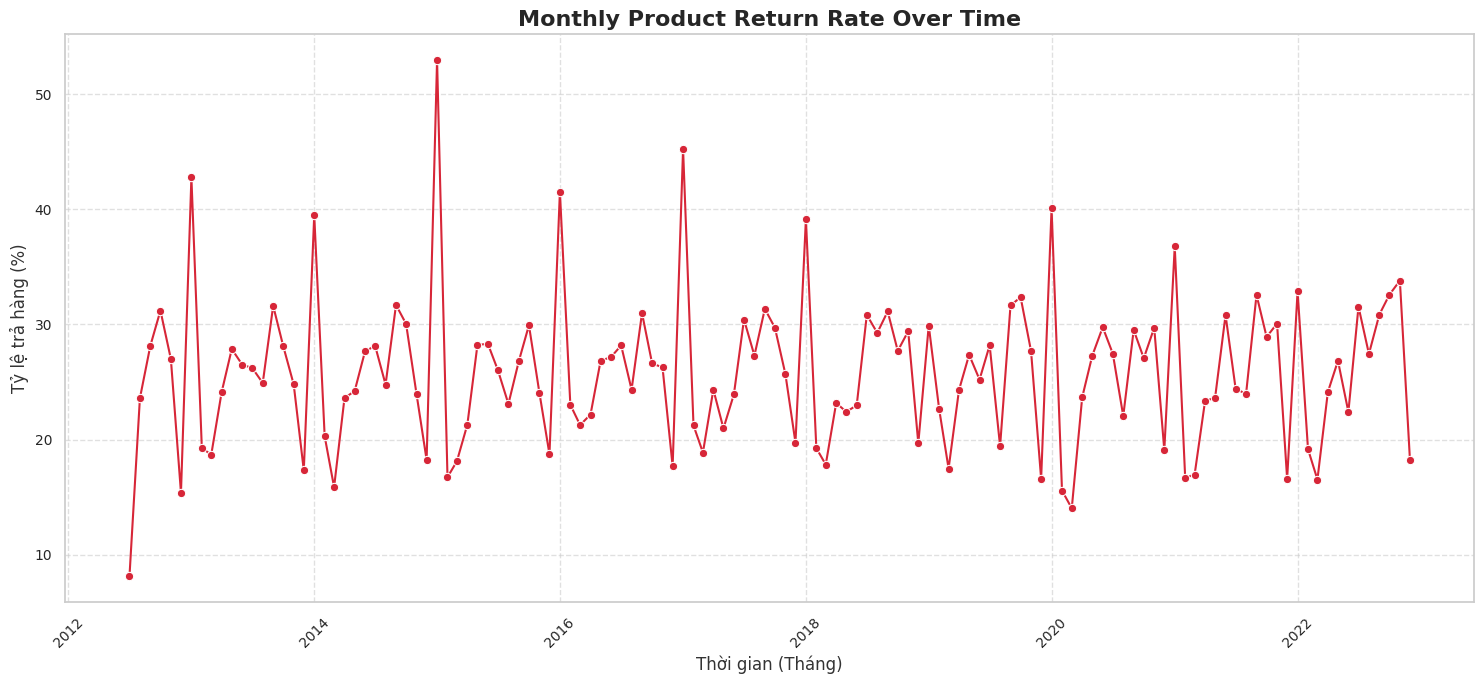

In [ ]:
# Đảm bảo cột ngày là datetime
df_orders_with_product_counts['order_date'] = pd.to_datetime(df_orders_with_product_counts['order_date'])
df_returns['return_date'] = pd.to_datetime(df_returns['return_date'])

# Bước 1: Tính tổng sản phẩm đã đặt theo tháng
df_orders_with_product_counts['order_year_month'] = df_orders_with_product_counts['order_date'].dt.to_period('M')
monthly_ordered_products = df_orders_with_product_counts.groupby('order_year_month')['num_products'].sum().reset_index()
monthly_ordered_products.rename(columns={'num_products': 'ordered_products_count'}, inplace=True)

# Bước 2: Tính tổng sản phẩm bị trả lại theo tháng
# Merge df_returns với df_order_items để lấy số lượng sản phẩm bị trả
df_returns_with_products = pd.merge(df_returns, df_order_items[['order_id', 'product_id', 'quantity']], on=['order_id', 'product_id'], how='left')

df_returns_with_products['return_year_month'] = df_returns_with_products['return_date'].dt.to_period('M')
monthly_returned_products = df_returns_with_products.groupby('return_year_month')['quantity'].sum().reset_index(name='returned_products_count')

# Bước 3: Hợp nhất dữ liệu và tính tỷ lệ trả lại hàng theo tháng
monthly_data = pd.merge(monthly_ordered_products, monthly_returned_products,
                        left_on='order_year_month', right_on='return_year_month', how='outer').fillna(0)

monthly_data['return_rate_monthly'] = (monthly_data['returned_products_count'] / monthly_data['ordered_products_count']) * 100
monthly_data['date'] = monthly_data['order_year_month'].dt.to_timestamp()

print("Dữ liệu sản phẩm đặt/trả và tỷ lệ trả hàng theo tháng:")
display(monthly_data.head())

# Trực quan hóa tỷ lệ trả lại hàng theo tháng
plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='return_rate_monthly', data=monthly_data, marker='o', color=GRIDBREAKER_COLORS['alert'])
plt.title('Monthly Product Return Rate Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian (Tháng)', fontsize=12)
plt.ylabel('Tỷ lệ trả hàng (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Dữ liệu sản phẩm đặt/trả và tỷ lệ trả hàng theo năm:


,order_year,ordered_products_count,return_year,returned_products_count,return_rate_yearly
0,2012,37006,2012,7943,21.464087
1,2013,87340,2013,22166,25.378979
2,2014,91084,2014,22761,24.989021
3,2015,92535,2015,23316,25.196953
4,2016,90892,2016,23407,25.752541


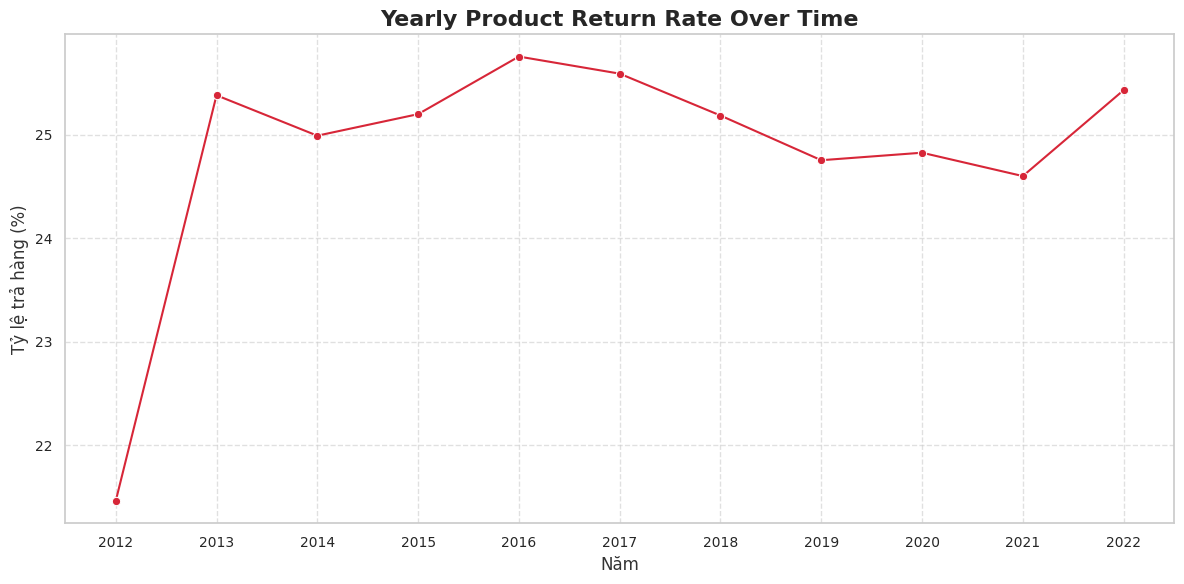

In [ ]:
# Bước 4: Tính tổng sản phẩm đã đặt theo năm
df_orders_with_product_counts['order_year'] = df_orders_with_product_counts['order_date'].dt.year
yearly_ordered_products = df_orders_with_product_counts.groupby('order_year')['num_products'].sum().reset_index()
yearly_ordered_products.rename(columns={'num_products': 'ordered_products_count'}, inplace=True)

# Bước 5: Tính tổng sản phẩm bị trả lại theo năm
df_returns_with_products['return_year'] = df_returns_with_products['return_date'].dt.year
yearly_returned_products = df_returns_with_products.groupby('return_year')['quantity'].sum().reset_index(name='returned_products_count')

# Bước 6: Hợp nhất dữ liệu và tính tỷ lệ trả lại hàng theo năm
yearly_data = pd.merge(yearly_ordered_products, yearly_returned_products,
                       left_on='order_year', right_on='return_year', how='outer').fillna(0)

yearly_data['return_rate_yearly'] = (yearly_data['returned_products_count'] / yearly_data['ordered_products_count']) * 100

print("\nDữ liệu sản phẩm đặt/trả và tỷ lệ trả hàng theo năm:")
display(yearly_data.head())

# Trực quan hóa tỷ lệ trả lại hàng theo năm
plt.figure(figsize=(12, 6))
sns.lineplot(x='order_year', y='return_rate_yearly', data=yearly_data, marker='o', color=GRIDBREAKER_COLORS['alert'])
plt.title('Yearly Product Return Rate Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tỷ lệ trả hàng (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(yearly_data['order_year'].unique())
plt.tight_layout()
plt.show()

In [ ]:
yearly_data

,order_year,ordered_products_count,return_year,returned_products_count,return_rate_yearly
0,2012,37006,2012,7943,21.464087
1,2013,87340,2013,22166,25.378979
2,2014,91084,2014,22761,24.989021
3,2015,92535,2015,23316,25.196953
4,2016,90892,2016,23407,25.752541
5,2017,83689,2017,21414,25.587592
6,2018,75132,2018,18921,25.183677
7,2019,44921,2019,11119,24.752343
8,2020,37237,2020,9244,24.824771
9,2021,36749,2021,9040,24.599309


In [ ]:
# Lưu DataFrame yearly_data vào một file CSV
output_file_path = 'yearly_data.csv'
yearly_data.to_csv(output_file_path, index=False)

# Cung cấp liên kết tải xuống
from google.colab import files
files.download(output_file_path)

print(f"DataFrame 'yearly_data' đã được lưu vào '{output_file_path}' và sẵn sàng để tải xuống.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DataFrame 'yearly_data' đã được lưu vào 'yearly_data.csv' và sẵn sàng để tải xuống.


### Thống kê lý do trả hàng

Thống kê số lượng theo từng lý do trả hàng:


,return_reason,count
0,wrong_size,13967
1,defective,8020
2,not_as_described,7035
3,changed_mind,6931
4,late_delivery,3986


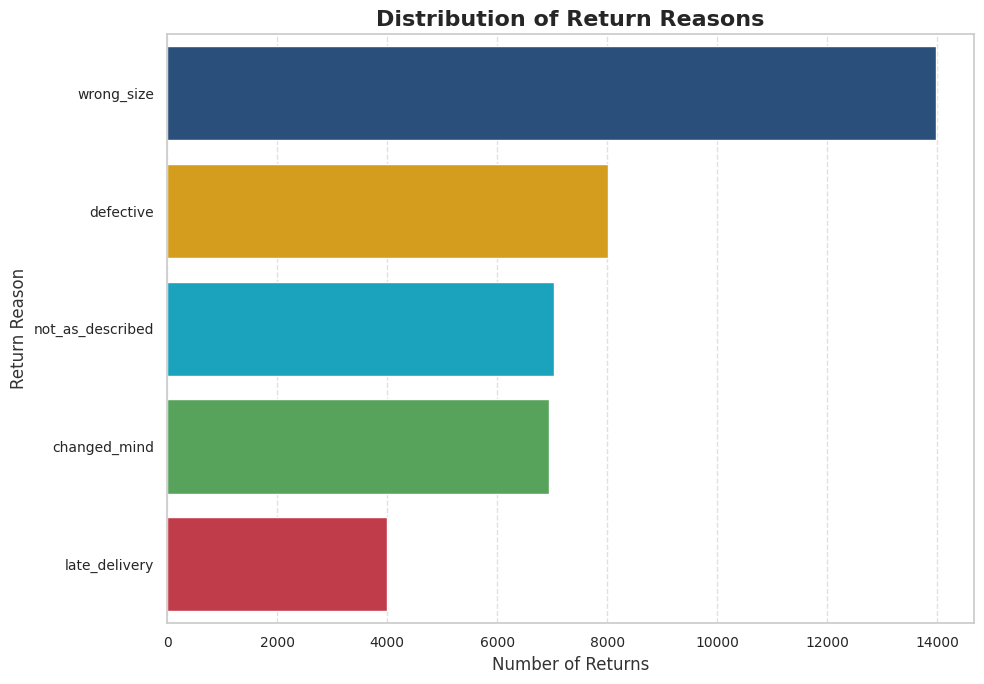

In [ ]:
# Thống kê số lượng từng lý do trả hàng
return_reasons_counts = df_returns['return_reason'].value_counts().reset_index()
return_reasons_counts.columns = ['return_reason', 'count']

print("Thống kê số lượng theo từng lý do trả hàng:")
display(return_reasons_counts)

# Trực quan hóa các lý do trả hàng
plt.figure(figsize=(10, 7))
sns.barplot(x='count', y='return_reason', data=return_reasons_counts, palette=CUSTOM_PALETTE)
plt.title('Distribution of Return Reasons', fontsize=16, fontweight='bold')
plt.xlabel('Number of Returns', fontsize=12)
plt.ylabel('Return Reason', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()